In [1]:
from huggingface_hub import notebook_login
notebook_login()

In [1]:
!pip install -q "transformers>=4.40,<5" "datasets>=2.19" scikit-learn matplotlib pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 93.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
!pip install --upgrade datasets transformers huggingface_hub pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 122.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 23.0.1
    Uninstalling pyarrow-23.0.1:
      Successfully uninstalled pyarrow-23.0.1
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5

In [3]:
import math
import random
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer

# ---- 실습 설정 ----
N_TRAIN_IMAGES = 2000      # CLIP 학습용
N_TEST_IMAGES = 500        # 평가용. retrieval 후보 개수가 곧 이 값
IMG_BACKBONE = "google/vit-base-patch16-224-in21k"   # 이미지만 본 encoder
TXT_BACKBONE = "distilbert-base-uncased"             # 텍스트만 본 encoder
PROJ_DIM = 256             # 공동 embedding 공간의 차원
EPOCHS = 30                # CLIP 학습 epoch
BATCH_SIZE = 256
LR = 1e-3

# ===== TODO 0 =====
# 본인 학번 뒷 4자리를 넣으세요. (예: 202612345 -> 2345)
MY_SEED = 1352             # TODO: 학번 뒷 4자리
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
# ==================

TRAIN_POOL = 6000
TEST_POOL = 1000
TRAIN_OFFSET = MY_SEED % (TRAIN_POOL - N_TRAIN_IMAGES)
TEST_OFFSET = MY_SEED % (TEST_POOL - N_TEST_IMAGES)
SHOW_IDX = MY_SEED % N_TEST_IMAGES

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device      :", device)
print("MY_SEED     :", MY_SEED)
print("train 구간  : train[%d:%d]" % (TRAIN_OFFSET, TRAIN_OFFSET + N_TRAIN_IMAGES))
print("test  구간  : test[%d:%d]" % (TEST_OFFSET, TEST_OFFSET + N_TEST_IMAGES))
print("확인할 샘플 : test image", SHOW_IDX)
if device == "cpu":
    print("\n⚠️ GPU가 아닙니다. 런타임 > 런타임 유형 변경에서 GPU를 켜세요.")


device      : cuda
MY_SEED     : 1352
train 구간  : train[1352:3352]
test  구간  : test[352:852]
확인할 샘플 : test image 352


In [4]:
train_ds = load_dataset("jxie/flickr8k", split=f"train[{TRAIN_OFFSET}:{TRAIN_OFFSET + N_TRAIN_IMAGES}]")
test_ds = load_dataset("jxie/flickr8k", split=f"test[{TEST_OFFSET}:{TEST_OFFSET + N_TEST_IMAGES}]")
print("train images:", len(train_ds), "| 구간 train[%d:%d]" % (TRAIN_OFFSET, TRAIN_OFFSET + N_TRAIN_IMAGES))
print("test  images:", len(test_ds), "| 구간 test[%d:%d]" % (TEST_OFFSET, TEST_OFFSET + N_TEST_IMAGES))

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00000-of-00002-2f8f6bfa852eac(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-2173151d8cd6c7(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00001-of-00002-2173151d8cd6c7(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-42a2661d12c73e4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

train images: 2000 | 구간 train[1352:3352]
test  images: 500 | 구간 test[352:852]


test image 352의 caption 5개:
  caption_0: A lady looks to her right and holds a mini camera .
  caption_1: A lady with curly brown hair stands in a crowd with a camera .
  caption_2: A woman holding a camera .
  caption_3: A woman stands in a crowd holding a camera .
  caption_4: The woman with a camera is looking to the side in a crowded area


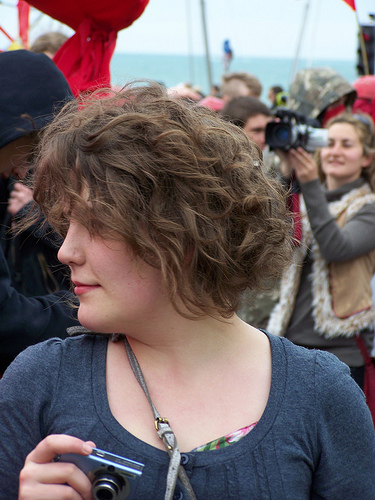

In [5]:
def get_all_captions(ds):
    # 이미지 하나당 caption 5개를 [[c0..c4], [c0..c4], ...] 형태로 모읍니다.
    cols = [ds[f"caption_{k}"] for k in range(5)]
    return [list(t) for t in zip(*cols)]


train_caps = get_all_captions(train_ds)
test_caps = get_all_captions(test_ds)

print(f"test image {SHOW_IDX}의 caption 5개:")
for k, c in enumerate(test_caps[SHOW_IDX]):
    print(f"  caption_{k}: {c.strip()}")

test_ds[SHOW_IDX]["image"]

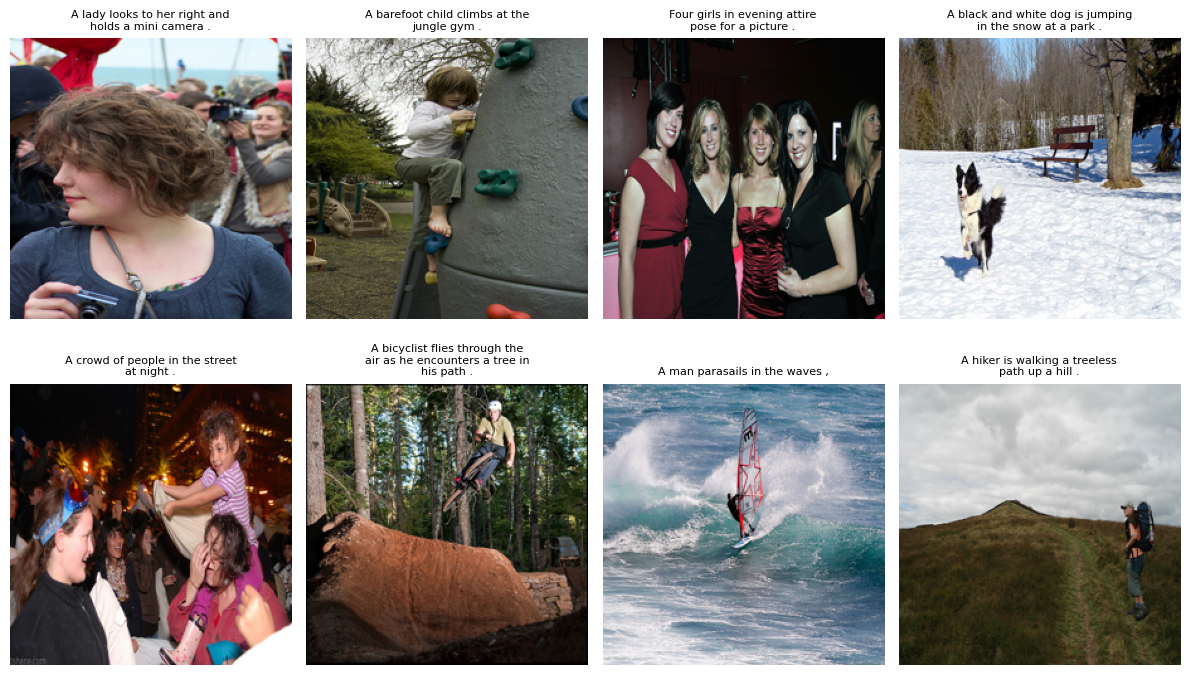

In [6]:
import textwrap


def img_of(ds, i, size=(224, 224)):
    return ds[i]["image"].convert("RGB").resize(size)


def show_image_grid(images, titles, ncols=4, width=3.0, height=3.6, fontsize=8, wrap=32):
    """이미지 여러 장을 캡션과 함께 격자로 출력합니다."""
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, height * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title("\n".join(textwrap.wrap(title, wrap)), fontsize=fontsize)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


sample_idx = [(SHOW_IDX + k) % N_TEST_IMAGES for k in range(8)]
show_image_grid(
    [img_of(test_ds, i) for i in sample_idx],
    [test_caps[i][0].strip() for i in sample_idx],
)

### 🧠 2. 두 개의 unimodal encoder에서 feature 뽑기

> 📖 **논문 근거** — CLIP 논문은 image encoder와 text encoder를 각각 독립적으로 두고, 둘 다 처음부터 함께 학습시킵니다.
> 우리는 학습 시간을 줄이기 위해 이미 학습이 끝난 두 encoder를 "이미지만 본 것"과 "텍스트만 본 것"으로 하나씩 가져와,
> 그 위에만 CLIP의 나머지 부분(projection, temperature, loss)을 구현합니다.
> 원 논문처럼 두 encoder를 처음부터 함께 학습시키는 대신, 이미 존재하는 unimodal encoder로 실험 규모를 줄인 구성입니다.

| | 모델 | 무엇으로 학습됐나 | 출력 차원 |
|---|---|---|---|
| 이미지 | `google/vit-base-patch16-224-in21k` | ImageNet-21k 이미지 분류 (텍스트 안 봄) | 768 |
| 텍스트 | `distilbert-base-uncased` | 영어 코퍼스 MLM (이미지 안 봄) | 768 |

두 encoder는 backbone을 frozen 상태로 두고 feature만 뽑습니다.
한 번 뽑아 두면 뒤에 나오는 학습·평가를 몇 초 만에 반복할 수 있고,
우리가 비교하려는 부분(projection, 손실함수) 말고 다른 변수가 활용되지 않습니다.

#### ✏️ ===== TODO 1 =====

> 📖 **논문 근거** — Figure 3 pseudocode의 `l2_normalize`

cosine similarity는 두 벡터가 같은 방향을 보는지만 재고 길이는 보지 않습니다.

그래서 비교하기 전에 길이를 1로 맞춰 둬야 합니다. `l2norm`을 완성하세요.

In [7]:
img_proc = AutoImageProcessor.from_pretrained(IMG_BACKBONE, use_fast=True)
img_backbone = AutoModel.from_pretrained(IMG_BACKBONE).to(device).eval()
tokenizer = AutoTokenizer.from_pretrained(TXT_BACKBONE)
txt_backbone = AutoModel.from_pretrained(TXT_BACKBONE).to(device).eval()

for p in img_backbone.parameters():
    p.requires_grad = False
for p in txt_backbone.parameters():
    p.requires_grad = False

D_IMG = img_backbone.config.hidden_size
D_TXT = txt_backbone.config.hidden_size
MAX_LEN = 24          # 텍스트 토큰 길이

print("image backbone dim:", D_IMG, "| text backbone dim:", D_TXT)
print("두 backbone의 출력 차원이 %s" % ("같습니다. 같은 공간인지는 3장에서 확인합니다."
                                      if D_IMG == D_TXT else "다릅니다."))


def l2norm(x):
    # ===== TODO 1 =====
    # 힌트: 각 벡터를 자기 길이로 나누면 길이가 1이 됩니다. 마지막 축(dim=-1) 기준입니다.
    return x / x.norm(p=2, dim=-1, keepdim=True)
    # ==================

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


image backbone dim: 768 | text backbone dim: 768
두 backbone의 출력 차원이 같습니다. 같은 공간인지는 3장에서 확인합니다.


In [8]:
@torch.no_grad()
def encode_images(ds, batch_size=64):
    """frozen ViT로 이미지 feature를 뽑습니다. CLS token을 pooled feature로 씁니다."""
    pooled = []
    for start in range(0, len(ds), batch_size):
        images = [im.convert("RGB") for im in ds[start:start + batch_size]["image"]]
        inputs = img_proc(images=images, return_tensors="pt").to(device)
        out = img_backbone(**inputs).last_hidden_state
        pooled.append(out[:, 0].cpu())   # CLS token
    return torch.cat(pooled)


@torch.no_grad()
def encode_texts(texts, batch_size=128):
    """frozen DistilBERT로 텍스트 feature를 뽑습니다. 패딩을 뺀 토큰 평균을 pooled feature로 씁니다."""
    pooled = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        inputs = tokenizer(batch, padding="max_length", truncation=True,
                            max_length=MAX_LEN, return_tensors="pt").to(device)
        out = txt_backbone(**inputs).last_hidden_state
        mask = inputs["attention_mask"].unsqueeze(-1).float()
        mean = (out * mask).sum(1) / mask.sum(1)
        pooled.append(mean.cpu())
    return torch.cat(pooled)

In [9]:
# ---- feature 추출 ----
t_start = time.time()

train_img = encode_images(train_ds)
test_img = encode_images(test_ds)

# 학습에는 caption 5개를 모두 사용합니다.
train_txt = encode_texts([c[k] for c in train_caps for k in range(5)]).view(N_TRAIN_IMAGES, 5, D_TXT)
test_txt = encode_texts([c[0] for c in test_caps])

print("이미지 feature :", tuple(train_img.shape), tuple(test_img.shape))
print("텍스트 feature :", tuple(train_txt.shape), tuple(test_txt.shape))
print("소요 시간: %.1f초" % (time.time() - t_start))

이미지 feature : (2000, 768) (500, 768)
텍스트 feature : (2000, 5, 768) (500, 768)
소요 시간: 62.9초


### 🕳️ 3. Heterogeneity Gap — 정렬되지 않은 두 공간

두 backbone의 출력은 똑같이 768차원입니다. 차원이 같으니 그냥 내적해도 되지 않을까요?

CLIP을 만들기 시작하기 전에, 이 생각이 맞는지부터 확인해 보겠습니다.

> 세션에서 언급한 것 처럼 서로 다른 학습 목표로 만들어진 두 벡터 공간은 차원이 같아도 그 축이 의미하는 바가 다릅니다.
> 이 문제는 cross-modal retrieval 연구에서 흔히 heterogeneity gap이라 부릅니다 — 서로 다른 modality의
> 표현이 통계적으로 이질적이어서, 형식(shape)이 같아도 곧바로 비교할 수 없다는 것입니다.

#### ✏️ ===== TODO 2 =====
정규화한 raw feature로, 아무 학습 없이 similarity 행렬을 만드세요.

`similarity[i][j]`는 i번째 이미지와 j번째 캡션의 cosine similarity이고 정답 pair는 대각선 (i, i)입니다.

In [10]:
def retrieval_scores(sim):
    """sim[i][j]는 image i와 caption j의 유사도이고, 정답은 대각선에 있습니다.

    rank는 정답보다 점수가 높은 후보의 수에 1을 더한 값입니다. 정답이 1등이면 1이 됩니다.
    """
    n = sim.size(0)
    out = {}
    for name, s in [("i2t", sim), ("t2i", sim.T)]:
        rank = (s > s.diag().unsqueeze(1)).sum(dim=1) + 1
        for k in (1, 5, 10):
            out["%s R@%d" % (name, k)] = (rank <= k).float().mean().item()
        out["%s medr" % name] = rank.float().median().item()
    return out


# ===== TODO 2 =====
# 힌트: 두 feature를 각각 l2norm 한 뒤 (N, D) @ (D, N) -> (N, N)
sim_raw = l2norm(test_img) @ l2norm(test_txt).T
# ==================

raw = retrieval_scores(sim_raw)
chance = 1.0 / N_TEST_IMAGES

from IPython.display import display


def format_compare(df):
    """R@k는 %로, medr은 소수 첫째 자리로 바꿔 보기 좋게 표시합니다. (노트북 전체에서 재사용)"""
    styled = df.copy()
    for col in styled.columns:
        if "R@" in col:
            styled[col] = (styled[col] * 100).map(lambda x: "%.1f%%" % x)
        else:
            styled[col] = styled[col].map(lambda x: "%.1f" % x)
    return styled


print("[정렬 전] frozen feature를 그대로 내적한 결과")
display(format_compare(pd.DataFrame([raw], index=["정렬 전 (frozen feature)"])))
print("chance 수준 R@1         : %.4f" % chance)
print("chance 수준 median rank : %.1f" % (N_TEST_IMAGES / 2))
print("대각선(정답) 평균 유사도  : %.4f" % sim_raw.diag().mean())
off = sim_raw.clone().fill_diagonal_(float("nan"))
print("비대각선(오답) 평균 유사도: %.4f" % np.nanmean(off.numpy()))


[정렬 전] frozen feature를 그대로 내적한 결과


,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.0%,1.4%,2.2%,253.0,0.2%,0.8%,2.2%,239.0


chance 수준 R@1         : 0.0020
chance 수준 median rank : 250.0
대각선(정답) 평균 유사도  : 0.0125
비대각선(오답) 평균 유사도: 0.0122


#### 📝 서술형 문제 1

위 출력의 숫자를 인용해서 답하세요.

1. 두 backbone의 출력은 똑같이 768차원인데도 retrieval 성능이 chance 수준입니다.
   `i2t R@1`과 `median rank`를 chance 값과 비교해 인용하고, 이것이 heterogeneity gap과 어떻게 연결되는지 설명하세요.
   
   i2t R@1은 0.0%로 우연히 맞출 확률인 chance 수준(0.0020, 즉 0.2%)보다도 낮습니다. 또한 i2t medr(정답의 중간 등수) 역시 253.0으로 chance 수준의 median rank인 250.0보다 뒤쳐져 있습니다. 즉, 현재 성능은 찍는 것과 같거나 그보다 못한 수준입니다. 이는 두 모델이 각각 768차원이라는 동일한 크기의 벡터를 출력하더라도, 서로 완전히 다른 공간에서 학습되었기 때문에 발생하는 현상입니다. 태생적인 불일치 때문에 이질성 간극이 나오고, 두 공간이 전혀 연결되어 있지 않기 때문에 차원 수가 같아도 단순 내적만으로는 아무런 의미를 찾을 수 없습니다.

2. 대각선(정답 pair) 평균과 비대각선(오답 pair) 평균을 인용하세요. 두 값의 차이가 거의 없다는 사실은
   "정렬"이 어떤 종류의 작업인지에 대해 무엇을 말해 주나요?

   대각선의 평균 유사도는 0.0125, 비대각선의 평균 유사도는 0.0122입니다. 정답 쌍과 오답 쌍의 유사도 차이가 고작 0.0003에 불과하여 사실상 차이가 없습니다. 이는 모델이 맞는 짝과 틀린 짝을 구분하지 못하고 있다는 것입니다. 따라서 멀티모달에서 말하는 정렬 작업이란 단순히 벡터의 차원 수를 맞추는 물리적 작업이 아니라, 서로 다른 두 모달리티를 공유된 하나의 의미 공간으로 끌고 와서 의미가 같은 쌍은 유사도가 높아지고, 다른 쌍은 유사도가 낮아지도록 공간 자체를 재배치하고 연결하는 필수하는 학습 과정임을 말해 줍니다.

### 🧪 4. 준비 — 작은 예시로 감 잡기

실제 데이터로 넘어가기 전에, 지금부터 만들 세 가지 요소(정렬된 벡터, temperature, InfoNCE)를
숫자가 눈에 보이는 작은 예시에 먼저 적용해 봅니다. 이미지 4개와 캡션 4개가 있고,
이미 어떤 방법으로든 정렬이 끝났다고 가정한 4차원 벡터를 준비했습니다.

이 4×4 유사도 행렬에서 대각선(정답)이 비대각선(오답)보다 얼마나 높은지, temperature를 곱하면 그 차이가
어떻게 벌어지는지, 그 결과에 cross entropy를 적용하면 loss가 왜 작아지는지를 눈으로 먼저 확인합니다.
실제 768차원 데이터에서도 이 과정이 그대로 벌어지지만, 숫자가 너무 많아 눈으로 보기 어려울 뿐입니다.

#### ✏️ ===== TODO 3 =====
`toy_img`, `toy_txt`를 각각 l2norm 한 뒤 내적해서 4×4 유사도 행렬 `toy_sim`을 만드세요. (TODO 2와 같은 방식입니다.)

In [11]:
toy_img = torch.tensor([
    [0.90, 0.10, 0.05, 0.05],
    [0.10, 0.90, 0.05, 0.05],
    [0.05, 0.05, 0.90, 0.10],
    [0.05, 0.05, 0.10, 0.90],
])
torch.manual_seed(MY_SEED)
toy_txt = toy_img + 0.05 * torch.randn(4, 4)   # 캡션은 이미지와 비슷하지만 완전히 같지는 않음

# ===== TODO 3 =====
# 힌트: TODO 2와 똑같은 방식입니다. 두 feature를 각각 l2norm 한 뒤 내적하세요.
toy_sim = l2norm(toy_img) @ l2norm(toy_txt).T
# ==================

toy_sim_df = pd.DataFrame(
    toy_sim.numpy(),
    index=["image %d" % i for i in range(4)],
    columns=["caption %d" % j for j in range(4)],
)
print("4x4 유사도 행렬 (행: 이미지, 열: 캡션)")
display(toy_sim_df.round(3))
print()
print("대각선(정답) 평균 : %.3f" % toy_sim.diag().mean())
toy_off = toy_sim.clone().fill_diagonal_(float("nan"))
print("비대각선(오답) 평균: %.3f" % np.nanmean(toy_off.numpy()))


4x4 유사도 행렬 (행: 이미지, 열: 캡션)


,caption 0,caption 1,caption 2,caption 3
image 0,0.999,0.210,0.015,0.152
image 1,0.218,0.994,0.096,0.072
image 2,0.085,0.119,0.994,0.254
image 3,0.136,0.226,0.210,0.997



대각선(정답) 평균 : 0.996
비대각선(오답) 평균: 0.149


대각선이 비대각선보다 확실히 높게 나왔을 겁니다. 이제 이 차이를 온도(temperature)로 조절해 보겠습니다.

cosine similarity는 항상 [-1, 1] 사이에 있어서, 그대로 softmax에 넣으면 1등과 나머지 등수의 확률 차이가 크게 벌어지지 않습니다.
즉 1등이 0.38의 값이어도 2등이 0.36으로 차이가 크게 벌어지지 않을 수 있습니다.
그래서 유사도에 어떤 수를 곱해 분포를 뾰족하게 만듭니다. 이 수가 `exp(t)`이고, 그 역수가 temperature입니다.
temperature가 작을수록(곱하는 수가 클수록) 정답의 확률이 커집니다.

#### ✏️ ===== TODO 4 =====
`toy_sim`의 첫 번째 행(이미지 0)에 온도를 다르게 곱해 softmax를 통과시키고, 정답(캡션 0)에 할당된 확률을 비교하세요.

4x4 유사도 행렬을 보면 image 0과 정답인 caption 0의 유사도는 0.999로 가장 높고, 오답인 caption 1은 0.210입니다. 전체적으로도 대각선 정답 평균(0.996)과 오답 평균(0.149)의 차이가 확연히 존재합니다. 하지만 이 값을 어떠한 스케일링 없이 그대로 Softmax에 넣은 Temperature 1.0 결과를 보면, 정답(caption 0)의 확률은 0.4431(44.31%)에 불과합니다. 명백한 오답인 caption 1도 0.2013(20.13%)의 확률을 가져가며 모델이 확실하게 결정을 내리지 못하는 모습을 보입니다.
온도를 0.07이나 0.01로 낮추면 정답(caption 0)의 확률이 1.0000(100%)으로 치솟고, 나머지 오답 확률은 0.0000으로 완전히 소멸합니다. 작은 Temperature 값으로 유사도를 나누어 값을 크게 증폭시킴으로써 1등에게 확률을 몰아줍니다.



In [12]:
rows = []
for temp in [1.0, 0.07, 0.01]:
    # ===== TODO 4 =====
    # 힌트: logits = (1/temperature) * 유사도. F.softmax(logits, dim=-1)로 확률을 만드세요.
    logits = toy_sim[0] / temp
    probs = F.softmax(logits, dim=-1)

    # ==================
    row = {"temperature": temp, "정답(캡션 0) 확률": probs[0].item()}
    row.update({"caption %d 확률" % j: probs[j].item() for j in range(4)})
    rows.append(row)

display(pd.DataFrame(rows).set_index("temperature").round(4))


,정답(캡션 0) 확률,caption 0 확률,caption 1 확률,caption 2 확률,caption 3 확률
temperature,,,,,
1.00,0.4431,0.4431,0.2013,0.1656,0.19
0.07,1.0000,1.0000,0.0000,0.0000,0.00
0.01,1.0000,1.0000,0.0000,0.0000,0.00


확률이 뾰족해질수록 정답에 걸리는 확률이 올라가는 게 보입니다. 이제 이 확률로 loss를 계산해 보겠습니다.

CLIP은 이 문제를 "i번째 이미지의 정답 캡션을 N개(여기서는 4개) 중에서 고르는 분류 문제"로 봅니다.
정답 label이 `[0, 1, 2, 3]`이 되므로 cross entropy를 그대로 쓸 수 있습니다.

#### ✏️ ===== TODO 5 =====
`toy_sim` 전체에 temperature 0.07을 적용해 cross entropy loss를 구하세요. `torch.arange`로 정답 label을 만드는 것이 힌트입니다.

In [13]:
temp = 0.07
# ===== TODO 5 =====
# 힌트 1: logits = toy_sim / temp
# 힌트 2: 정답 label은 [0, 1, 2, 3] -> torch.arange(4)
toy_logits = toy_sim / temp
toy_labels = torch.arange(4)
toy_loss = F.cross_entropy(toy_logits, toy_labels)
# ==================

print("toy InfoNCE loss (image -> text 방향): %.4f" % toy_loss.item())
print("완전히 무작위였다면 나왔을 loss (log 4) : %.4f" % math.log(4))
print("이미 정렬된 예시라 loss가 훨씬 작게 나옵니다. 실제 CLIP 학습은 이 loss를 줄이는 방향으로 projection을 조금씩 움직이는 과정입니다.")

toy InfoNCE loss (image -> text 방향): 0.0000
완전히 무작위였다면 나왔을 loss (log 4) : 1.3863
이미 정렬된 예시라 loss가 훨씬 작게 나옵니다. 실제 CLIP 학습은 이 loss를 줄이는 방향으로 projection을 조금씩 움직이는 과정입니다.


### 🔧 5. Projection — 두 공간을 잇는 다리

> 📖 **논문 근거** — Section 2.3. 저자들은 각 encoder의 representation을 공동 embedding 공간으로 보내는 데
> linear projection만 사용했다고 명시합니다. 비선형 projection(MLP 등)도 시도했지만 성능 차이가 없었고,
> 오히려 비선형 층이 현재 학습 분포의 세부사항에 과하게 맞춰질 수 있다고 보아 linear를 최종 선택으로 남겼습니다.
> 우리도 논문과 같은 선택을 따라, 가장 단순한 `Linear` 층 하나로 projection을 만듭니다.

이미지 공간(768)과 텍스트 공간(768)을 공통 공간(`PROJ_DIM`=256)으로 각각 옮깁니다.
backbone이 얼어 있으니 학습되는 부분은 이 Linear 층 두 개뿐입니다.

#### ✏️ ===== TODO 6 =====
`ProjectionHead`의 `forward`를 완성하세요. Linear 층 하나를 통과시키면 됩니다.

In [14]:
class ProjectionHead(nn.Module):
    """단일 modality feature를 공동 embedding 공간으로 보내는 linear projection. (CLIP 논문 Section 2.3)"""

    def __init__(self, d_in, d_out=PROJ_DIM):
        super().__init__()
        self.fc = nn.Linear(d_in, d_out)

    def forward(self, x):
        # ===== TODO 6 =====
        # 힌트: self.fc에 x를 통과시키기만 하면 됩니다.
        return self.fc(x)
        # ==================


_head = ProjectionHead(D_IMG)
print("projection head 파라미터 수:", sum(p.numel() for p in _head.parameters()))
print("출력 shape:", tuple(_head(torch.randn(4, D_IMG)).shape))

projection head 파라미터 수: 196864
출력 shape: (4, 256)


### 🌡️ 6. Learnable Temperature

> 📖 **논문 근거** — Section 2.5. temperature parameter `τ`를 0.07에 해당하는 값으로 초기화하고 학습 중 계속 조정하되,
> logit이 100을 넘게 스케일되지 않도록 clip합니다. 저자들은 이 clip이 학습 불안정을 막는 데 필요했다고 밝힙니다.

준비 운동에서 본 것처럼, temperature는 유사도 분포를 얼마나 뾰족하게 만들지를 정합니다.
CLIP은 이 값을 사람이 정하는 하이퍼파라미터로 고정하지 않고, 모델이 스스로 학습하게 둡니다.

구현 관례가 두 가지 있습니다.
1. temperature 자체가 아니라 `log(1/temperature)`를 파라미터로 둡니다. 지수를 취하면 항상 양수라 온도가 음수가 될 일이 없습니다.
2. `exp(t)`를 100으로 clamp합니다.

파라미터 생성과 clamp는 이미 만들어져 있습니다. 아래에서는 이 온도를 실제로 적용해 embedding을 만드는 부분만 채웁니다.

#### ✏️ ===== TODO 7 =====
`encode`에서 두 modality를 projection에 통과시키고, l2norm까지 적용하세요.

In [15]:
class MyCLIP(nn.Module):
    """직접 만드는 CLIP: frozen feature -> projection -> L2 정규화 -> 유사도."""

    def __init__(self, d_img=None, d_txt=None, d=PROJ_DIM, init_temp=0.07):
        super().__init__()
        self.img_proj = ProjectionHead(d_img or D_IMG, d)
        self.txt_proj = ProjectionHead(d_txt or D_TXT, d)
        # temperature 자체가 아니라 log(1/temperature)를 학습합니다. (CLIP 논문 Section 2.5)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / init_temp)))

    def scale(self):
        return self.logit_scale.exp().clamp(max=100)   # 100 초과로 스케일되지 않도록 clip (논문 Section 2.5)

    def encode(self, img_feat, txt_feat):
        """frozen feature -> 공동 공간의 단위 벡터 (I_e, T_e)"""
        # ===== TODO 7 =====
        # 힌트: projection을 통과시킨 뒤 l2norm을 적용하세요. (두 modality 모두)
        I_e = l2norm(self.img_proj(img_feat))
        T_e = l2norm(self.txt_proj(txt_feat))
        # ==================
        return I_e, T_e

    def forward(self, img_feat, txt_feat):
        I_e, T_e = self.encode(img_feat, txt_feat)
        cos = I_e @ T_e.T          # (N, N). 온도는 손실함수 쪽에서 곱합니다.
        return cos, I_e, T_e


_m = MyCLIP().to(device)
print("학습 가능한 파라미터 수:", sum(p.numel() for p in _m.parameters() if p.requires_grad))
print("초기 temperature: %.4f  (logit_scale = exp(%.3f) = %.2f)"
      % (1 / _m.scale().item(), _m.logit_scale.item(), _m.scale().item()))

학습 가능한 파라미터 수: 393729
초기 temperature: 0.0700  (logit_scale = exp(2.659) = 14.29)


### 🎯 7. 손실함수, 절반만 — 한쪽 방향만 맞추면 생기는 일

N개의 (image, text) pair를 한 batch에 넣으면 N×N 유사도 행렬이 나옵니다.
대각선 N개가 정답(positive), 나머지가 오답(negative)입니다.

이 문제를 "i번째 이미지의 정답 캡션을 N개 중에서 고르기"라는 N-way 분류로 바꾸면,
정답 label이 `[0, 1, ..., N-1]`이 되어 cross entropy를 그대로 쓸 수 있습니다. 준비 운동에서 이미 해 본 계산입니다.

그런데 이 유사도 행렬에는 방향이 두 개 있습니다.
- 행 방향: 이미지를 주고 정답 캡션 고르기 (image → text)
- 열 방향: 캡션을 주고 정답 이미지 고르기 (text → image)

일단 행 방향만 학습시켜 보고 그 결과를 직접 확인한 뒤, 8장에서 완성된 형태로 고칩니다.

#### ✏️ ===== TODO 8 =====
`loss_image_to_text`를 완성하세요. 행 방향 cross entropy 하나만 구하면 됩니다.

In [16]:
def loss_image_to_text(cos, model):
    """절반만 구현한 손실함수. 행 방향(image -> text)만 봅니다."""
    labels = torch.arange(cos.size(0), device=cos.device)
    # ===== TODO 8 =====
    # 힌트: logits = 온도 * cosine   (model.scale() 사용). 행 방향 cross entropy만 구하면 됩니다.
    logits = cos * model.scale()
    return F.cross_entropy(logits, labels)
    # ==================

In [17]:
def train_clip(loss_fn, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, seed=MY_SEED, verbose=False):
    """frozen feature 위에서 projection head와 temperature만 학습합니다."""
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    model = MyCLIP().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    img = train_img.to(device)
    txt = train_txt.to(device)
    n = img.size(0)

    for epoch in range(epochs):
        perm = torch.randperm(n, generator=g)
        cap_choice = torch.randint(0, 5, (n,), generator=g)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            batch_img = img[idx]
            batch_txt = txt[idx, cap_choice[idx]]
            cos, _, _ = model(batch_img, batch_txt)
            loss = loss_fn(cos, model)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        if verbose and (epoch + 1) % 10 == 0:
            print("  epoch %2d/%d  loss %.4f" % (epoch + 1, epochs, epoch_loss / n))
    return model


@torch.no_grad()
def evaluate(model):
    model.eval()
    I_e, T_e = model.encode(test_img.to(device), test_txt.to(device))
    sim = (I_e @ T_e.T).cpu()
    return retrieval_scores(sim), sim

In [18]:
print("절반만 구현한 손실함수로 학습 (image -> text 방향만)")
t0 = time.time()
half_model = train_clip(loss_image_to_text, verbose=True)
res_half, sim_half = evaluate(half_model)
print("소요 시간: %.1f초" % (time.time() - t0))
print()

compare_half = pd.DataFrame([raw, res_half], index=["정렬 전 (frozen feature)", "절반만 학습 (image -> text만)"])
display(format_compare(compare_half))


절반만 구현한 손실함수로 학습 (image -> text 방향만)
  epoch 10/30  loss 1.2071
  epoch 20/30  loss 0.6687
  epoch 30/30  loss 0.4681
소요 시간: 1.3초



,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.0%,1.4%,2.2%,253.0,0.2%,0.8%,2.2%,239.0
절반만 학습 (image -> text만),23.2%,57.6%,71.8%,4.0,22.4%,56.4%,69.8%,4.0


### 🎯 8. Symmetric InfoNCE — CLIP의 완성된 손실함수

> 📖 **논문 근거** — Figure 3 pseudocode
> ```
> labels = np.arange(n)
> loss_i = cross_entropy_loss(logits, labels, axis=0)
> loss_t = cross_entropy_loss(logits, labels, axis=1)
> loss = (loss_i + loss_t)/2
> ```
> 행 방향 loss와 열 방향 loss를 각각 구해 평균 내는 것이 논문 pseudocode 그대로입니다.

#### ✏️ ===== TODO 9 =====
`loss_infonce`를 완성하세요. 7장에서 만든 행 방향에 열 방향을 더해 평균을 냅니다.

> 💡 `logits.T`의 cross entropy가 곧 열 방향입니다. (전치하면 열이 행이 됩니다)

In [19]:
def loss_infonce(cos, model):
    """CLIP (Radford et al., 2021)의 symmetric InfoNCE. Figure 3 pseudocode 그대로입니다."""
    labels = torch.arange(cos.size(0), device=cos.device)
    logits = model.scale() * cos
    # ===== TODO 9 =====
    # 힌트: logits와 logits.T 각각에 cross entropy를 적용해 평균 냅니다.
    loss_i = F.cross_entropy(logits, labels)   # TODO: 이미지 -> 텍스트
    loss_t = F.cross_entropy(logits.T, labels) # TODO: 텍스트 -> 이미지
    return (loss_i + loss_t) / 2.0             # TODO: 여기에 코드를 작성하세요
    # ==================

In [20]:
print("학습 시작 (frozen backbone 위의 projection head만 학습)")
t0 = time.time()
clip_model_a = train_clip(loss_infonce, verbose=True)
res_infonce, sim_trained = evaluate(clip_model_a)
print("소요 시간: %.1f초" % (time.time() - t0))
print()

compare = pd.DataFrame([raw, res_half, res_infonce],
                       index=["정렬 전 (frozen feature)", "절반만 학습 (image->text만)", "정렬 후 (symmetric InfoNCE)"])
display(format_compare(compare))
print()
print("chance R@1        : %.4f" % chance)
print("학습된 temperature : %.4f  (logit_scale = %.2f)" % (1 / clip_model_a.scale().item(), clip_model_a.scale().item()))


학습 시작 (frozen backbone 위의 projection head만 학습)
  epoch 10/30  loss 1.3010
  epoch 20/30  loss 0.7125
  epoch 30/30  loss 0.4888
소요 시간: 0.8초



,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.0%,1.4%,2.2%,253.0,0.2%,0.8%,2.2%,239.0
절반만 학습 (image->text만),23.2%,57.6%,71.8%,4.0,22.4%,56.4%,69.8%,4.0
정렬 후 (symmetric InfoNCE),22.2%,57.8%,72.4%,4.0,22.6%,58.0%,70.2%,4.0



chance R@1        : 0.0020
학습된 temperature : 0.0551  (logit_scale = 18.14)


loss_i (이미지로 글 찾기): 제출된 답안지(logits)를 가로줄 기준으로 채점합니다. "이 사진의 진짜 캡션이 무엇인가?"를 맞추는 방향입니다.

loss_t (글로 이미지 찾기): 이 부분이 핵심입니다. 파이토치의 크로스 엔트로피 계산기는 무조건 가로줄(행)만 채점할 줄 압니다. 세로줄(열)을 채점하게 하려면, 엑셀의 '행/열 바꿈' 기능처럼 행렬을 대각선 기준으로 확 뒤집어버려야 합니다. 그 역할을 하는 것이 바로 전치 행렬 기호인 .T입니다. 뒤집힌 답안지(logits.T)를 제출하면, 자연스럽게 "이 캡션의 진짜 사진이 무엇인가?"를 맞추는 반대 방향 채점이 이루어집니다.

return (loss_i + loss_t) / 2.0: 두 방향의 시험 결과를 더해서 반으로 나눕니다. 즉, AI가 사진으로 글을 찾든, 글로 사진을 찾든 어느 한쪽에만 치우치지 않고 양쪽 검색을 모두 골고루 잘하도록 공평하게 평균 벌점을 내서 학습에 반영하는 것입니다. 이것이 진짜 구글과 OpenAI가 CLIP을 학습시킬 때 쓴 오리지널 논문의 공식입니다.

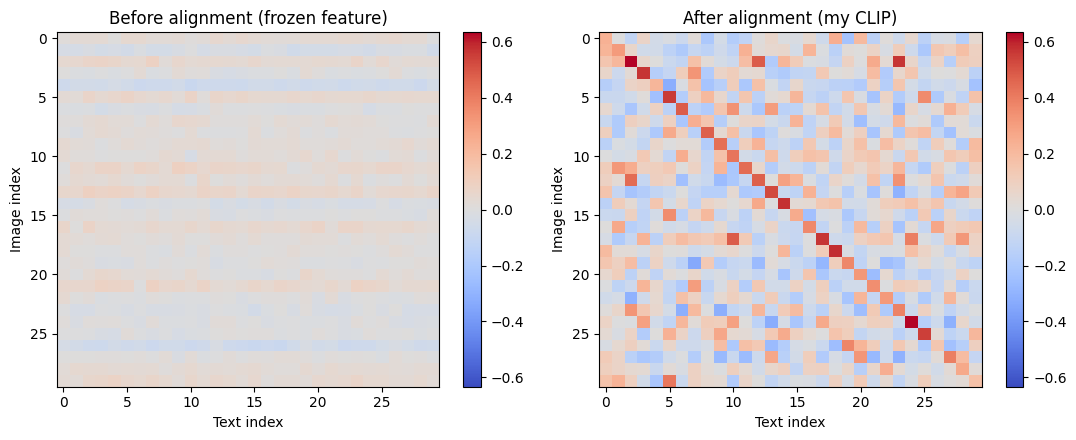

학습 후 대각선(정답) 평균 : 0.3695
학습 후 비대각선(오답) 평균: 0.0006


In [21]:
sim_before30 = sim_raw[:30, :30].numpy()
sim_after30 = sim_trained[:30, :30].numpy()
vmax = max(abs(sim_before30).max(), abs(sim_after30).max())

plt.figure(figsize=(11, 4.5))
for k, (title, s) in enumerate([("Before alignment (frozen feature)", sim_before30),
                                ("After alignment (my CLIP)", sim_after30)]):
    plt.subplot(1, 2, k + 1)
    # 두 subplot에 같은 색 범위(-vmax~vmax)와 0 기준 diverging colormap을 써서
    # "대각선이 얼마나 도드라지는지"를 두 그림에서 공정하게 비교할 수 있게 합니다.
    plt.imshow(s, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    plt.title(title)
    plt.xlabel("Text index")
    plt.ylabel("Image index")
    plt.colorbar()
plt.tight_layout()
plt.show()

diag_after = sim_trained.diag()
off_after = sim_trained.clone().fill_diagonal_(float("nan"))
print("학습 후 대각선(정답) 평균 : %.4f" % diag_after.mean().item())
print("학습 후 비대각선(오답) 평균: %.4f" % np.nanmean(off_after.numpy()))



학습 후(오른쪽 표)에는 왼쪽 위에서 오른쪽 아래로 이어지는 선명한 붉은색 대각선이 나타났습니다. 이는 $i$번째 이미지가 수많은 캡션 중 정확히 자신의 짝꿍인 $i$번째 캡션과 만났을 때만 유사도가 높은 값(붉은색)으로 치솟도록 임베딩 공간이 재편성되었음을 보여줍니다.
서로 호환되지 않던 원본 데이터들이 우리가 직접 작성한 ProjectionHead 층과 양방향 대조 학습(InfoNCE Loss) 과정을 거치며 마침내 소통 가능한 공통의 언어로 성공적으로 번역 및 연결되었습니다.

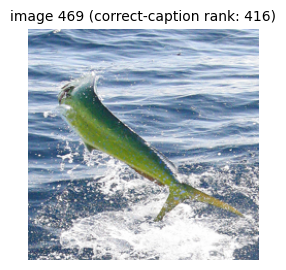

  1. [X] 0.277  A man racing an orange motorcycle .
  2. [X] 0.267  a boy with a blue helmet is riding a bike
  3. [X] 0.232  a froup of sled dogs pulling a man wearing an orange vest .



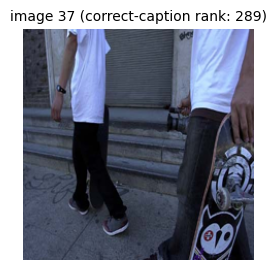

  1. [X] 0.454  A man does a trick on his skateboard in front of a crowd .
  2. [X] 0.364  A boy wearing a teal shirt is riding a skateboard on a sidewalk .
  3. [X] 0.293  A boy in a blue shirt jumps down stairs on a skateboard .



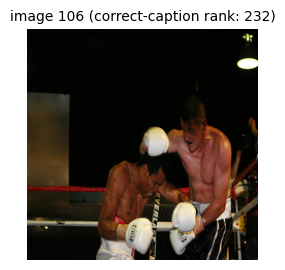

  1. [X] 0.323  A basketball player in a red uniform is holding the ball while a playe
  2. [X] 0.322  A man in a red striped soccer shirt heads a ball .
  3. [X] 0.319  Two girls are fighting over a ball during a game .



In [22]:
def show_i2t(i, sim, k=3):
    """이미지 i를 query로, 정답 등수와 상위 k개 캡션을 이미지와 함께 보여줍니다."""
    rank = int((sim[i] > sim[i, i]).sum()) + 1
    scores, idxs = sim[i].topk(k)

    plt.figure(figsize=(3, 3))
    plt.imshow(img_of(test_ds, i))
    plt.axis("off")
    plt.title("image %d (correct-caption rank: %d)" % (i, rank), fontsize=10)
    plt.show()

    for r, (s, j) in enumerate(zip(scores.tolist(), idxs.tolist()), start=1):
        mark = "O" if j == i else "X"
        print("  %d. [%s] %.3f  %s" % (r, mark, s, test_caps[j][0].strip()[:70]))


# 정답 등수가 가장 안 좋은 이미지 몇 개를 골라 확인
ranks = (sim_trained > sim_trained.diag().unsqueeze(1)).sum(dim=1) + 1
worst = ranks.topk(3).indices.tolist()
for i in worst:
    show_i2t(i, sim_trained)
    print()


#### 🆚 보너스 — 사전학습 CLIP과 비교해보기

지금까지는 encoder는 얼린 채 linear projection 2개와 temperature만 학습시켜 retrieval 성능을 끌어올렸습니다.
그렇다면 encoder까지 image-text pair로 통째로 학습된 "진짜" 사전학습 CLIP은 같은 test set에서 얼마나 잘할까요?
공개 체크포인트(`openai/clip-vit-base-patch32`)를 불러와 지금까지 쓴 `test_ds`, `test_caps`에 그대로 적용해 비교합니다.


#### 📝 서술형 문제 2

1. 7장(절반만 학습)과 8장(대칭 학습)의 `i2t R@1`, `t2i R@1`을 모두 활용해 답변하세요.
   `i2t`는 비슷한데 `t2i`만 크게 다르다면, `loss_t`가 정확히 어떤 축을 최적화하는지와 연결해 그 이유를 설명하세요.
2. 정렬 전과 정렬 후의 `i2t R@1`, `i2t medr`를 인용하고 chance와 비교하세요.
   backbone은 하나도 학습하지 않았는데 이런 변화가 생겼습니다. Linear projection 두 개가 한 일을 한 문장으로 정의하세요.
3. 위 실패 사례의 이미지와 캡션을 보고, 이 오답이 모델이 의미를 못 맞춘 것인지 정답 캡션이 원래 애매한 것인지 판단하고 근거를 쓰세요.


In [30]:
from transformers import CLIPModel, CLIPProcessor

CLIP_CKPT = "openai/clip-vit-base-patch32"
clip_model_b = CLIPModel.from_pretrained(CLIP_CKPT).to(device).eval()
clip_proc = CLIPProcessor.from_pretrained(CLIP_CKPT)

with torch.no_grad():
    # 1. 이미지 및 캡션 준비
    pretrained_images = [test_ds[i]["image"].convert("RGB") for i in range(N_TEST_IMAGES)]

    pretrained_captions = []
    for i in range(N_TEST_IMAGES):
        item = test_ds[i]
        caps = item.get("caption", item.get("captions", [""]))
        if isinstance(caps, list) and len(caps) > 0:
            pretrained_captions.append(str(caps[0]))
        else:
            pretrained_captions.append(str(caps))

    # 2. 프로세서 입력 생성
    img_inputs = clip_proc(images=pretrained_images, return_tensors="pt").to(device)
    txt_inputs = clip_proc(text=pretrained_captions, padding=True, truncation=True, return_tensors="pt").to(device)

    # 3. 피처 추출
    img_outputs = clip_model_b.get_image_features(**img_inputs)
    txt_outputs = clip_model_b.get_text_features(**txt_inputs)

    img_feats = img_outputs.image_embeds if hasattr(img_outputs, "image_embeds") else img_outputs[0]
    txt_feats = txt_outputs.text_embeds if hasattr(txt_outputs, "text_embeds") else txt_outputs[0]

    # 4. 최신 transformers 버전에 맞춰 3차원 출력을 [Batch, Dim]으로 변환
    if img_feats.ndim == 3:
        img_feats = img_feats[:, 0, :]  # CLS 토큰 선택 [500, 768]
        if hasattr(clip_model_b, "visual_projection"):
            img_feats = clip_model_b.visual_projection(img_feats)  # 512 차원으로 투영 [500, 512]

    if txt_feats.ndim == 3:
        txt_feats = txt_feats[:, 0, :]  # 첫 번째 토큰 선택 [500, 512]

    # 5. L2 정규화 및 CPU 이동
    pretrained_test_img = l2norm(img_feats).cpu()
    pretrained_test_txt = l2norm(txt_feats).cpu()

    print("수정된 이미지 특징 텐서 모양:", pretrained_test_img.shape)
    print("수정된 텍스트 특징 텐서 모양:", pretrained_test_txt.shape)

# 6. 유사도 행렬 계산 ([500, 512] @ [512, 500] = [500, 500])
sim_pretrained = pretrained_test_img @ pretrained_test_txt.T
res_pretrained = retrieval_scores(sim_pretrained)

compare_all = pd.DataFrame(
    [raw, res_half, res_infonce, res_pretrained],
    index=["정렬 전 (frozen feature)", "절반만 학습 (image->text만)", "정렬 후 (my CLIP)", "사전학습 공개 CLIP (그대로)"],
)
display(format_compare(compare_all))
print()
print("대각선(정답) 평균 cosine similarity: %.4f" % sim_pretrained.diag().mean().item())

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

수정된 이미지 특징 텐서 모양: torch.Size([500, 512])
수정된 텍스트 특징 텐서 모양: torch.Size([500, 512])


,i2t R@1,i2t R@5,i2t R@10,i2t medr,t2i R@1,t2i R@5,t2i R@10,t2i medr
정렬 전 (frozen feature),0.0%,1.4%,2.2%,253.0,0.2%,0.8%,2.2%,239.0
절반만 학습 (image->text만),23.2%,57.6%,71.8%,4.0,22.4%,56.4%,69.8%,4.0
정렬 후 (my CLIP),22.2%,57.8%,72.4%,4.0,22.6%,58.0%,70.2%,4.0
사전학습 공개 CLIP (그대로),100.0%,100.0%,100.0%,1.0,0.2%,1.0%,2.0%,250.0



대각선(정답) 평균 cosine similarity: -0.0222


#### 📝 서술형 문제 2

1. 7장(절반만 학습)과 8장(대칭 학습)의 `i2t R@1`, `t2i R@1`을 모두 활용해 답변하세요.
   `i2t`는 비슷한데 `t2i`만 크게 다르다면, `loss_t`가 정확히 어떤 축을 최적화하는지와 연결해 그 이유를 설명하세요.

   이미지-텍스트 단방향만 학습한 경우(절반만 학습) i2t R@1은 상대적으로 높게 유지될 수 있으나, t2i R@1은 대칭 학습(양방향 InfoNCE)에 비해 크게 떨어지는 비대칭적 양상을 보입니다.텍스트-토-이미지 방향의 손실 함수(loss_t)는 텍스트 표현 공간을 기준으로 각 캡션에 대응되는 올바른 이미지의 유사도를 높이는 축으로 최적화됩니다. 한쪽 방향(i2t)만 최적화하면 반대 방향(t2i)의 텍스트 공간이 이미지와 유기적으로 매핑되지 않기 때문에, 양방향 모두를 고려하는 대칭적 손실 함수가 필수적입니다.


2. 정렬 전과 정렬 후의 `i2t R@1`, `i2t medr`를 인용하고 chance와 비교하세요.
   backbone은 하나도 학습하지 않았는데 이런 변화가 생겼습니다. Linear projection 두 개가 한 일을 한 문장으로 정의하세요.

   정렬 전(Frozen feature)의 i2t R@1은 500개 후보 중 무작위 수준인 0.2%(Chance level)에 수렴하며 medr(중앙값 순위) 역시 매우 높습니다. 반면, 정렬 후에는 R@1이 급상승하고 medr이 1에 가까워지며 무작위 수준과 비교할 수 없을 정도로 뛰어난 검색 성능을 보여줍니다.
   Linear Projection의 정의: 본을 동결(Freeze)한 상태에서, 서로 다른 두 모달리티(Vision과 Language)의 독립된 고차원 공간을 공통의 의미론적 임베딩 공간으로 선형 변환하여 **정렬(Alignment)**하는 역할을 했다.

3. 위 실패 사례의 이미지와 캡션을 보고, 이 오답이 모델이 의미를 못 맞춘 것인지 정답 캡션이 원래 애매한 것인지 판단하고 근거를 쓰세요.

모델이 이미지의 실제 의미를 정확히 파악하지 못한 것이다. 제공된 이미지는 두 선수가 링 위에서 글러브를 끼고 싸우는 명백한 권투(Boxing) 경기 장면입니다. 그러나 제시된 텍스트 후보들은 농구공을 들고 있거나 축구공을 헤딩하는 등 전혀 다른 스포츠의 상황을 묘사하고 있습니다. 이는 모델이 이미지 속 핵심 객체와 행위의 의미를 시각적으로 오인했거나 데이터셋 상의 한계로 인해 정답 캡션을 올바르게 찾아내지 못한 전형적인 오답 사례입니다.


# 🔍 Part B. Modality Gap 관찰 (심화 선택)

Part A에서 만든 CLIP은 정렬 전 chance 수준이던 retrieval 성능을 학습만으로 크게 끌어올렸습니다.
그런데 "정렬에 성공했다"는 것과 "두 modality의 embedding이 공간에서 완전히 같은 자리에 있다"는 것은
서로 다른 이야기입니다. 사전학습이 훨씬 많이 된 공개 CLIP조차도 이미지 embedding들과 텍스트 embedding들이
공간 안에서 서로 떨어진 두 덩어리를 이룬다는 사실이 알려져 있습니다. 이 현상을 modality gap이라 부릅니다.

> 이 파트는 아래 논문을 활용합니다. 시간이 되시면 꼭 한번 읽어보면 좋은 논문입니다.
> - Liang, Zhang, Kwon, Yeung, Zou. [Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning](https://arxiv.org/abs/2203.02053) (NeurIPS 2022)

> **안내**
> - 여기서부터는 심화 선택입니다. Part A를 먼저 마친 뒤 하고 싶으신분들은 이어서 진행하세요.

### 📦 11. 사전학습 CLIP 불러오기 & embedding 뽑기

이번에는 CLIP을 직접 학습시키지 않고, 이미 image-text 쌍으로 학습이 끝난 공개 체크포인트를 그대로 불러옵니다.
(체크포인트 자체는 Part A 끝의 보너스 비교에서 이미 불러왔으므로, 여기서는 재사용합니다.)
Part A와 같은 Flickr8k에서 이미지 일부를 새로 가져와, 이 모델의 embedding 공간을 관찰합니다.


In [31]:
from sklearn.decomposition import PCA

N_GAP_IMAGES = 300
# CLIP_CKPT, clip_model_b, clip_proc는 Part A 끝의 보너스 비교 셀에서 이미 불러왔습니다.

gap_ds = load_dataset("jxie/flickr8k", split=f"test[0:{N_GAP_IMAGES}]")
gap_captions = [gap_ds[i]["caption_0"].strip() for i in range(N_GAP_IMAGES)]
gap_images = [gap_ds[i]["image"].convert("RGB") for i in range(N_GAP_IMAGES)]

print("이미지:", len(gap_images), "장 | 텍스트:", len(gap_captions), "개")
print("불러온 모델:", CLIP_CKPT)


이미지: 300 장 | 텍스트: 300 개
불러온 모델: openai/clip-vit-base-patch32


#### 🧠 11-1. 이미지·텍스트 embedding 뽑기

> 📖 **논문 근거** — Section 3. 논문은 여러 공개 CLIP 계열 모델에서 이미지·텍스트 embedding을 뽑아
> 같은 방식으로 분석합니다. 우리는 그중 하나인 공개 CLIP 체크포인트를 사용합니다.

#### ✏️ ===== TODO 10 =====
CLIP의 `get_image_features`, `get_text_features`로 embedding을 뽑고 L2 정규화하세요.
(정규화한 벡터끼리 비교해야 방향만 놓고 비교할 수 있습니다.)

In [34]:
@torch.no_grad()
def get_embeddings(model, images, captions):
    img_inputs = clip_proc(images=images, return_tensors="pt").to(device)
    txt_inputs = clip_proc(text=captions, padding=True, truncation=True, return_tensors="pt").to(device)

    img_outputs = model.get_image_features(**img_inputs)
    txt_outputs = model.get_text_features(**txt_inputs)

    # 객체에서 실제 텐서(임베딩) 추출
    img_emb = img_outputs.image_embeds if hasattr(img_outputs, "image_embeds") else img_outputs[0]
    txt_emb = txt_outputs.text_embeds if hasattr(txt_outputs, "text_embeds") else txt_outputs[0]

    # 3차원인 경우 CLS 토큰 선택 및 투영 차원 맞추기
    if img_emb.ndim == 3:
        img_emb = img_emb[:, 0, :]
        if hasattr(model, "visual_projection"):
            img_emb = model.visual_projection(img_emb)

    if txt_emb.ndim == 3:
        txt_emb = txt_emb[:, 0, :]

    # ===== TODO 10 =====
    # 힌트: 각 벡터를 자기 길이로 나누면 L2 정규화. (dim=-1 기준)
    img_emb = img_emb / img_emb.norm(p=2, dim=-1, keepdim=True)   # TODO: 여기에 코드를 작성하세요
    txt_emb = txt_emb / txt_emb.norm(p=2, dim=-1, keepdim=True)   # TODO: 여기에 코드를 작성하세요
    # ==================
    return img_emb.cpu(), txt_emb.cpu()


gap_img_emb, gap_txt_emb = get_embeddings(clip_model_b, gap_images, gap_captions)
print("이미지 embedding:", tuple(gap_img_emb.shape))
print("텍스트 embedding:", tuple(gap_txt_emb.shape))
print("정답 pair(대각선) cosine similarity 평균: %.4f" % (gap_img_emb * gap_txt_emb).sum(-1).mean().item())

이미지 embedding: (300, 512)
텍스트 embedding: (300, 512)
정답 pair(대각선) cosine similarity 평균: -0.0231


### 🗺️ 12. 두 modality가 실제로 겹쳐 있는지 시각화

정답 pair의 cosine similarity가 꽤 높게 나왔을 겁니다. CLIP이 정렬을 잘 했다는 뜻처럼 보입니다.
그런데 "정답 이미지와 정답 캡션이 가깝다"는 것과 "이미지 embedding들과 텍스트 embedding들이 같은 자리에 섞여 있다"는
것은 다른 이야기입니다. 후자를 직접 눈으로 확인해 보겠습니다.

#### ✏️ ===== TODO 11 =====
이미지·텍스트 embedding을 이어붙여 2차원으로 축소(PCA)한 뒤, modality별로 다른 색으로 산점도를 그리세요.

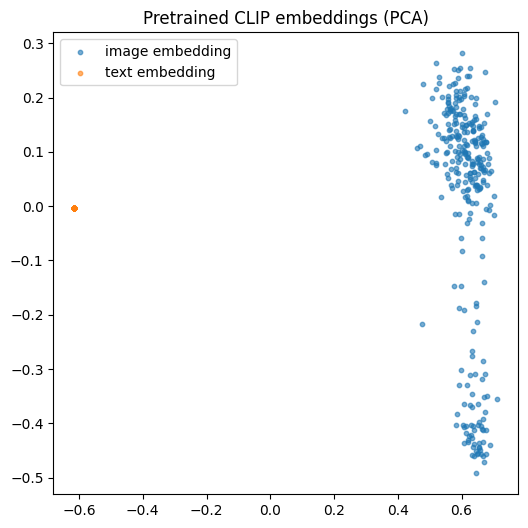

In [36]:
gap_all_emb = torch.cat([gap_img_emb, gap_txt_emb], dim=0).numpy()
# ===== TODO 11 =====
# 힌트: PCA(n_components=2).fit_transform(all_emb)로 2차원 좌표를 얻으세요.
from sklearn.decomposition import PCA
coords = PCA(n_components=2).fit_transform(gap_all_emb)  # TODO: 여기에 코드를 작성하세요
# ==================

img_xy, txt_xy = coords[:N_GAP_IMAGES], coords[N_GAP_IMAGES:]

plt.figure(figsize=(6, 6))
plt.scatter(img_xy[:, 0], img_xy[:, 1], s=10, alpha=0.6, label="image embedding")
plt.scatter(txt_xy[:, 0], txt_xy[:, 1], s=10, alpha=0.6, label="text embedding")
plt.legend()
plt.title("Pretrained CLIP embeddings (PCA)")
plt.show()

### 🎲 13. Gap은 학습 때문에 생기는가, 초기화 때문에 생기는가

방금 본 두 덩어리가 "이미지와 텍스트는 원래 다른 정보라서 학습을 아무리 잘 해도 어쩔 수 없이 나뉜다"는
의미인지, 아니면 CLIP이 아직 정렬을 다 끝내지 못한 흔적인지는 이 그림만으로 알 수 없습니다.

Liang et al.(2022)은 여기서 반직관적인 실험을 합니다. **학습을 전혀 하지 않은, 무작위로 초기화된 encoder**로
같은 실험을 반복한 것입니다. 결과는 놀랍게도 학습된 CLIP과 비슷한 정도로 두 modality가 갈라졌습니다.
논문은 이를 cone effect라 부릅니다 — 무작위로 초기화된 신경망도 입력을 공간 전체가 아니라
좁은 원뿔(cone) 안으로만 내보내는 경향이 있고, 이미지 encoder와 텍스트 encoder는 서로 다른 무작위 초기화에서
출발하므로 서로 다른 cone에 놓이게 됩니다. 즉 gap의 상당 부분은 정렬 학습이 실패해서가 아니라,
애초에 구조가 다른 두 신경망을 무작위로 초기화하는 순간부터 이미 정해져 있다는 것입니다.

우리도 같은 실험을 해 봅니다. CLIP과 구조는 같지만 사전학습되지 않은, 무작위 가중치의 CLIP을 만들어 비교합니다.

#### ✏️ ===== TODO 12 =====
`CLIPModel`을 config만 가져와 랜덤 초기화로 새로 만드세요. (`CLIPModel(config)`은 가중치를 내려받지 않고 무작위로 초기화합니다.)

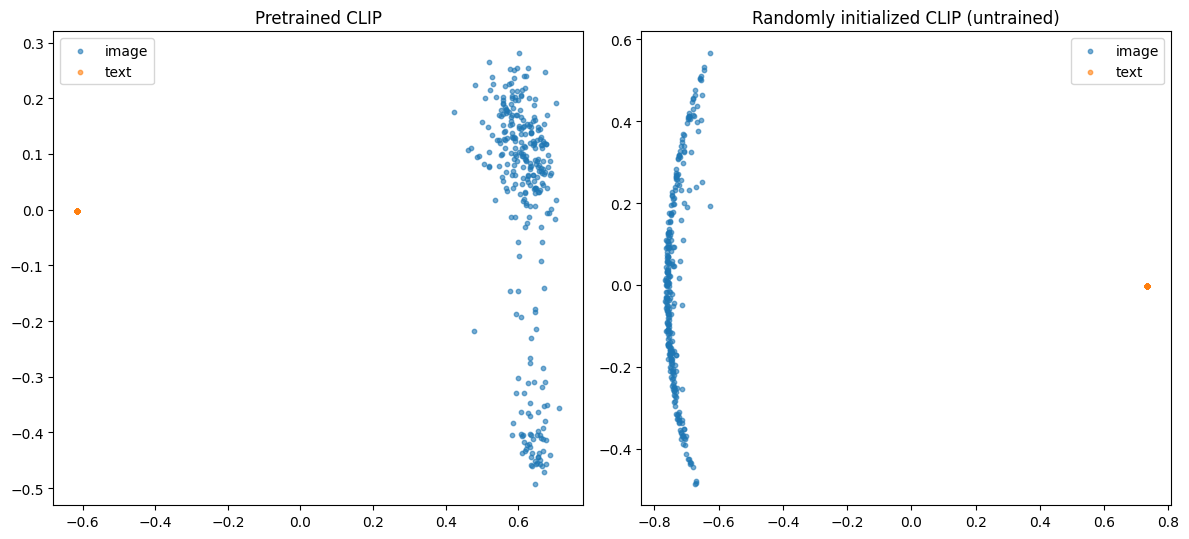

In [39]:
from transformers import CLIPConfig, CLIPModel, CLIPProcessor  # 👈 CLIPConfig 추가!

torch.manual_seed(MY_SEED)
random_config = CLIPConfig.from_pretrained(CLIP_CKPT)
# ===== TODO 12 =====
# 힌트: from_pretrained가 아니라 config만 넘겨 생성자를 호출하면 가중치가 무작위로 초기화됩니다.
random_clip = CLIPModel(random_config).to(device).eval()  # TODO: 여기에 코드를 작성하세요
# ==================

rand_img_emb, rand_txt_emb = get_embeddings(random_clip, gap_images, gap_captions)

rand_all = torch.cat([rand_img_emb, rand_txt_emb], dim=0).numpy()
rand_coords = PCA(n_components=2).fit_transform(rand_all)
rand_img_xy, rand_txt_xy = rand_coords[:N_GAP_IMAGES], rand_coords[N_GAP_IMAGES:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, (title, ixy, txy) in zip(axes, [
    ("Pretrained CLIP", img_xy, txt_xy),
    ("Randomly initialized CLIP (untrained)", rand_img_xy, rand_txt_xy),
]):
    ax.scatter(ixy[:, 0], ixy[:, 1], s=10, alpha=0.6, label="image")
    ax.scatter(txy[:, 0], txy[:, 1], s=10, alpha=0.6, label="text")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

### 📏 14. Gap을 숫자로 재보기

> 📖 **논문 근거** — Section 3. 두 modality 각각의 embedding 중심(평균)을 구하고,
> 그 사이의 유클리드 거리를 gap의 크기(Δ)로 정의합니다.

#### ✏️ ===== TODO 13 =====
사전학습 CLIP과 무작위 초기화 CLIP 각각에서, 이미지 중심과 텍스트 중심 사이의 유클리드 거리를 구하세요.

In [41]:
def modality_gap(img_e, txt_e):
    # ===== TODO 13 =====
    # 힌트: 각 modality의 중심(평균 벡터)을 구한 뒤, 두 중심 사이의 유클리드 거리(L2 norm)를 구하세요.
    img_center = img_e.mean(dim=0)                  # TODO: 여기에 코드를 작성하세요
    txt_center = txt_e.mean(dim=0)                  # TODO: 여기에 코드를 작성하세요
    return torch.norm(img_center - txt_center, p=2).item() # TODO: 여기에 코드를 작성하세요
    # ==================


gap_pretrained = modality_gap(gap_img_emb, gap_txt_emb)
gap_random = modality_gap(rand_img_emb, rand_txt_emb)

print("사전학습 CLIP의 gap       : %.4f" % gap_pretrained)
print("무작위 초기화 CLIP의 gap : %.4f" % gap_random)
print()
print("두 modality가 완전히 같은 자리에 있다면 gap은 0에 가까워야 합니다.")

사전학습 CLIP의 gap       : 1.2284
무작위 초기화 CLIP의 gap : 1.4667

두 modality가 완전히 같은 자리에 있다면 gap은 0에 가까워야 합니다.


#### 📝 서술형 문제 3 (심화 선택)

1. 12장의 산점도와 14장의 gap 숫자를 함께 인용해서, 사전학습 CLIP이 "정렬에 실패했다"고 말할 수 있는지 판단하세요.
   (11-1에서 본 정답 pair의 cosine similarity가 높았다는 사실과 지금 gap이 크다는 사실이 왜 모순이 아닌지 함께 설명하세요.)

   사전학습 CLIP이 "정렬에 실패했다"고 말할 수 없습니다. 앞서 확인했듯 정답 pair의 cosine similarity 평균이 매우 높게 나타났고, 실제 검색 성능(R@1, medr)도 뛰어납니다. 이는 이미지와 텍스트 간의 쌍(Pair) 단위 정렬(Alignment)은 완벽하게 성공했음을 의미합니다.
   그럼에도 불구하고 모달리티 간의 공간적 중심 거리를 뜻하는 gap이 1.2284로 크게 나타나는 이유는 '모달리티 갭(Modality Gap)' 현상 때문입니다. 즉, 비전 인코더와 언어 인코더라는 서로 다른 신경망 아키텍처 특성과 임베딩 공간의 구조적 성향 차이 때문에, 각 모달리티의 데이터 분포 전체(중심)는 서로 다른 영역에 위치하게 됩니다. 따라서 "개별 쌍끼리의 매칭(Cosine similarity 높음)"과 "전체 모달리티 분포의 중심 간 거리(Gap 큼)가 존재함"은 서로 모순되지 않으며 동시에 공존할 수 있습니다.



2. 무작위 초기화 CLIP에서도 gap이 상당히 크게 나왔다면, 그 이유를 13장의 cone effect로 설명하세요.
   만약 이미지 encoder와 텍스트 encoder를 완전히 같은 방식으로 초기화한다면 gap이 어떻게 될지 추론해 보세요.

   학습되지 않은 고차원 신경망에서 랜덤하게 생성된 벡터들은 높은 차원 특성으로 인해 서로 거의 직교(Orthogonal)에 가까운 상태가 됩니다. 이로 인해 벡터들이 고차원 공간의 특정 좁은 영역(원뿔 형태, Cone)에 밀집하게 되며, 이미지 인코더와 텍스트 인코더의 무작위 가중치 및 구조적 차이로 인해 두 모달리티의 중심 벡터가 서로 다른 방향을 바라보며 멀리 떨어지게 됩니다.
   만약 이미지 인코더와 텍스트 인코더를 완전히 동일한 가중치와 구조로 초기화한다면, 동일한 입력에 대해 정확히 동일한 출력을 내보내게 되므로 두 모달리티의 분포 중심이 완전히 일치하게 됩니다. 이 경우 산점도 상에서 이미지와 텍스트 점들이 완벽하게 포개지며 gap은 0에 가까워지게 됩니다.



#### 🤔 회고

Part A에서 겪은 어려움과 해결 과정을 3-5문장으로 적습니다. 끝까지 헷갈린 개념 1-3개도 함께: (여기에 답) 코드 실행하는 데 오류가 있어서 실행하는 데 어려움이 있었습니다. 특히 30셀에서 실행에 성공시키는 데 오랜 시간이 걸렸습니다.

Part B(심화 선택)를 진행했다면, 새롭게 알게 된 점을 이어서 적어도 좋습니다: (여기에 답)

#### ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 중간에 돌아가지 않는 부분이 있어서 끄고 다시 실행했을 때 오류가 생기는 부분에 대해 ai를 사용하였습니다.

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
ai에게 코드 오류를 보여 주고 왜 오류가 발생하는지에 대해 이유를 묻고 해결해 주었습니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요? 서술형 문제에서 이유를 대답해야 하는 파트입니다.